## AQS Scraping and visualizations
The first step will be to create an account with the EPA for their Air Quality System API. For the purposes of this notebook I am going to leave them blank, but to reproduce this you just need to add in your own api key. 

In [18]:
#Import necessary libraries
import matplotlib.pyplot as plt
import geopandas as gpd
import requests
import pandas as pd
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# This is where you (TA/Professor) will need to create an API key. If you would like to use mine, 
# please just email me at the email address listed below and I'll be happy to provide it
EMAIL = "hmchilders@ucdavis.edu"
KEY = "copperram67"

# AQS pollutant parameter codes
pollutants = {
    "PM25": "88101",
    "Ozone": "44201"
}

# (state_fips, county_fips)
counties = {
    "LosAngeles_CA": ("06", "037"),
    "Cook_IL": ("17", "031"),
    "Harris_TX": ("48", "201"),
    "Maricopa_AZ": ("04", "013"),
    "SanDiego_CA": ("06", "073"),
    "Orange_CA": ("06", "059"),
    "MiamiDade_FL": ("12", "086"),
    "Kings_NY": ("36", "047"),
    "Dallas_TX": ("48", "113"),
    "Riverside_CA": ("06", "065"),
}

years = [2019, 2021]

base_url = "https://aqs.epa.gov/data/api/annualData/byCounty"

all_dfs = []
failed = []

#For loop to use the API to get data for all 10 counties for both years (2019, 2021) 
# and both pollutants (ozone and PM2.5)
for county_name, (state, county) in counties.items():
    for pollutant_name, param in pollutants.items():
        for year in years:
            params = {
                "email": EMAIL,
                "key": KEY,
                "param": param,
                "bdate": f"{year}0101",
                "edate": f"{year}1231",
                "state": state,
                "county": county,
            }

            print(f"Downloading {county_name} | {pollutant_name} | {year} ...")

            try:
                r = requests.get(base_url, params=params, timeout=60)
                r.raise_for_status()
                payload = r.json()

                # AQS responses typically include: {"Header":[...], "Data":[...]}
                data = payload.get("Data", None)

                # If no data returned, keep track (some counties/years/pollutants may have no monitors)
                if not data:
                    failed.append((county_name, pollutant_name, year, "No data returned"))
                    continue

                df = pd.DataFrame(data)
                df["county_name"] = county_name
                df["pollutant"] = pollutant_name
                df["year"] = year

                all_dfs.append(df)

            except Exception as e:
                failed.append((county_name, pollutant_name, year, str(e)))

# Combine and save
if all_dfs:
    aqs_df = pd.concat(all_dfs, ignore_index=True)
    print("Total rows downloaded:", len(aqs_df))
    aqs_df.to_csv("aqs_annual_10counties_pm25_ozone_2019_2021.csv", index=False)
    print("Saved: aqs_annual_10counties_pm25_ozone_2019_2021.csv")
else:
    print("No dataframes were downloaded. Check EMAIL/KEY and parameters.")

# Print failures (if any)
if failed:
    print("\n--- Requests with no data / errors ---")
    for item in failed:
        print(item)

Total rows downloaded: 2767
Saved: aqs_annual_10counties_pm25_ozone_2019_2021.csv

--- Requests with no data / errors ---
('Kings_NY', 'Ozone', 2019, 'No data returned')
('Kings_NY', 'Ozone', 2021, 'No data returned')


Explore the data to ensure everything was downloaded and added to the csv correctly

In [20]:
aqs_data = pd.read_csv('aqs_annual_10counties_pm25_ozone_2019_2021.csv')
aqs_data.columns

Index(['state_code', 'county_code', 'site_number', 'parameter_code', 'poc',
       'latitude', 'longitude', 'datum', 'parameter', 'sample_duration_code',
       'sample_duration', 'pollutant_standard', 'metric_used', 'method',
       'year', 'units_of_measure', 'event_type', 'observation_count',
       'observation_percent', 'validity_indicator', 'valid_day_count',
       'required_day_count', 'exceptional_data_count',
       'null_observation_count', 'primary_exceedance_count',
       'secondary_exceedance_count', 'certification_indicator',
       'arithmetic_mean', 'standard_deviation', 'first_max_value',
       'first_max_datetime', 'second_max_value', 'second_max_datetime',
       'third_max_value', 'third_max_datetime', 'fourth_max_value',
       'fourth_max_datetime', 'first_max_nonoverlap_value',
       'first_max_n_o_datetime', 'second_max_nonoverlap_value',
       'second_max_n_o_datetime', 'ninety_ninth_percentile',
       'ninety_eighth_percentile', 'ninety_fifth_percentile'

### Workflow

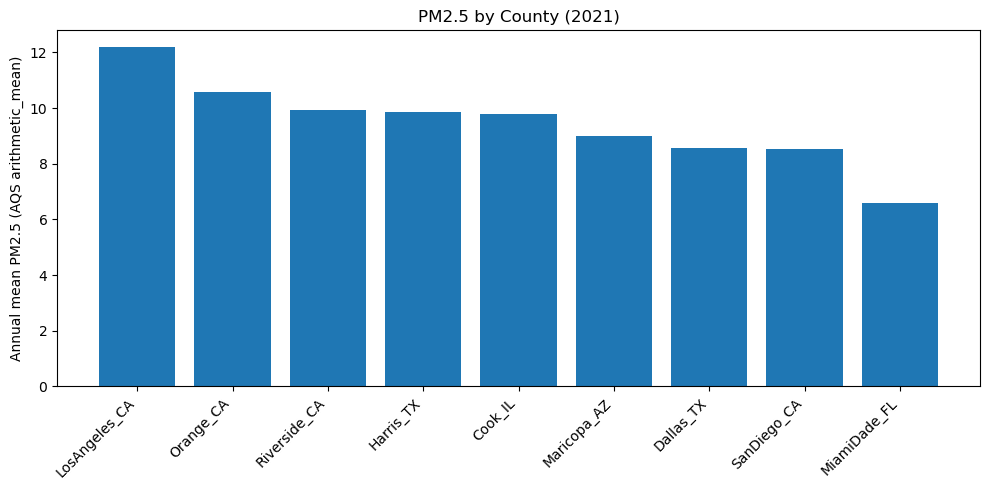

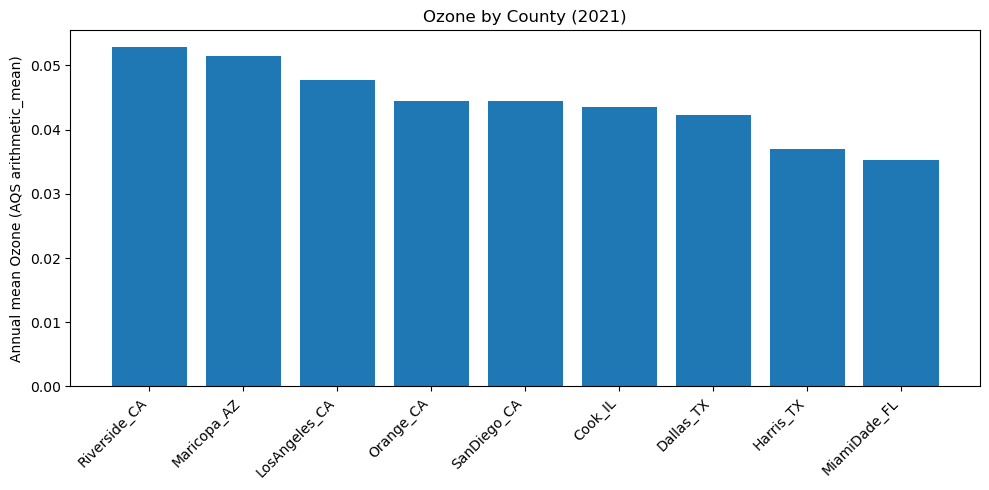

/var/folders/47/h_qs1w2n1p3bbhgw5ddnx8900000gn/T/ipykernel_57542/3950067307.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


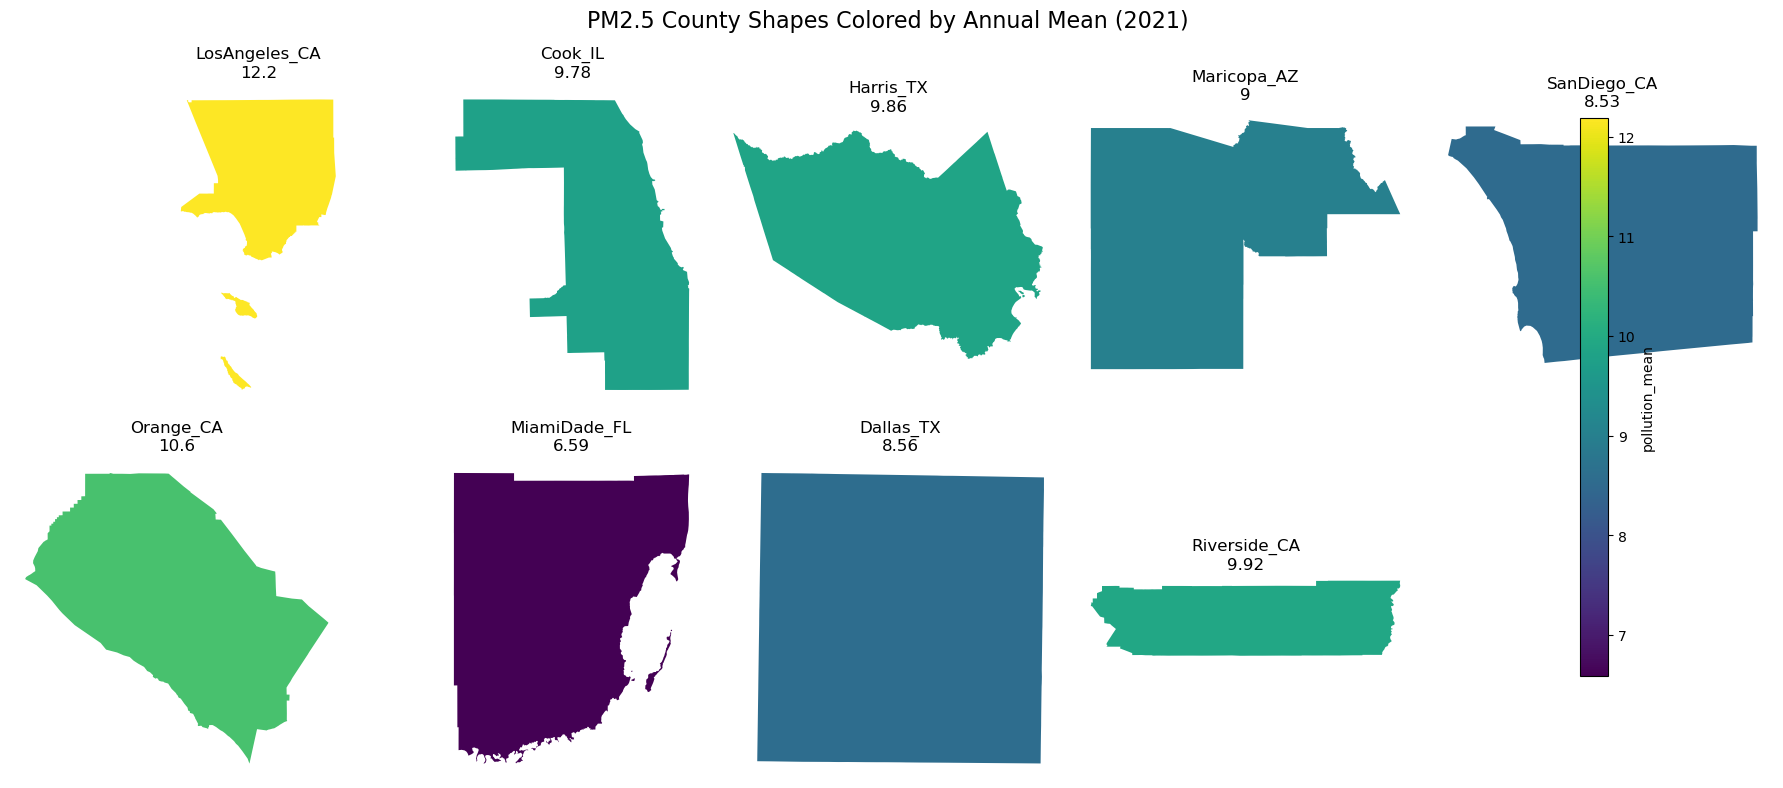

/var/folders/47/h_qs1w2n1p3bbhgw5ddnx8900000gn/T/ipykernel_57542/3950067307.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


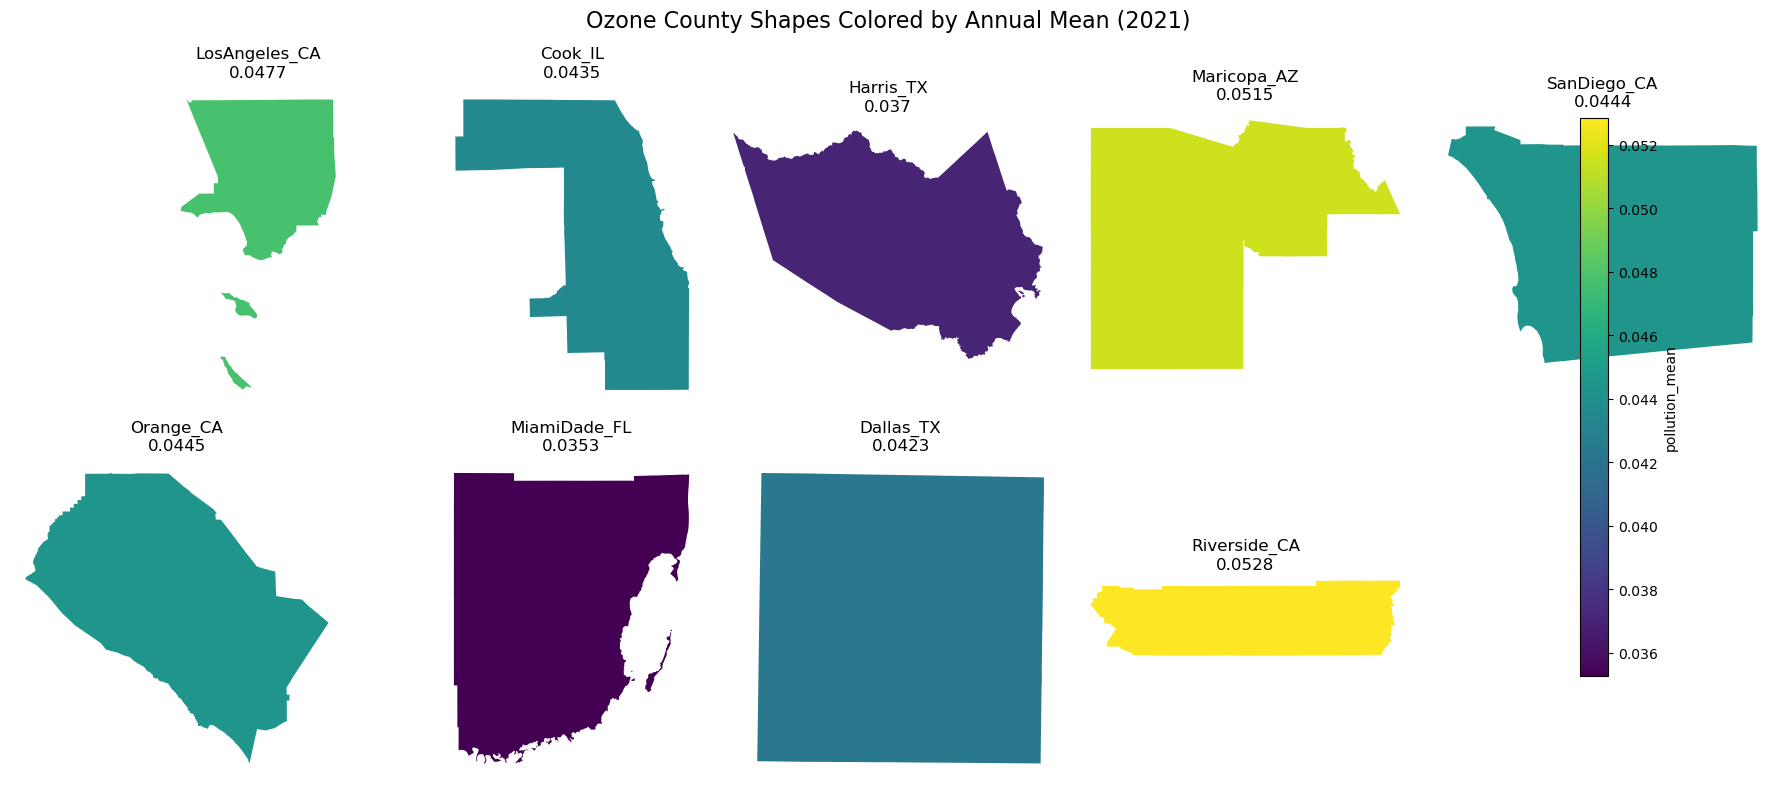

In [21]:
# ----------------------------
# Setup
#----------------------------

YEAR_MODE = "2021"  

# List of counties
COUNTIES = [
    "LosAngeles_CA",
    "Cook_IL",
    "Harris_TX",
    "Maricopa_AZ",
    "SanDiego_CA",
    "Orange_CA",
    "MiamiDade_FL",
    "Dallas_TX",
    "Riverside_CA",
]

# AQS pollutant labels
PM_LABEL = "PM25"
O3_LABEL = "Ozone"

# County FIPS for joining to geometry (state_fips, county_fips)
COUNTY_FIPS = {
    "LosAngeles_CA": ("06", "037"),
    "Cook_IL": ("17", "031"),
    "Harris_TX": ("48", "201"),
    "Maricopa_AZ": ("04", "013"),
    "SanDiego_CA": ("06", "073"),
    "Orange_CA": ("06", "059"),
    "MiamiDade_FL": ("12", "086"),
    "Dallas_TX": ("48", "113"),
    "Riverside_CA": ("06", "065"),
}

# ----------------------------
# Build a clean county-level table from aqs_df
# ----------------------------
def county_pollution_summary(aqs_df: pd.DataFrame, pollutant: str, year_mode: str) -> pd.DataFrame:
    """
    Returns county-level summary pollution for a pollutant.
    Uses arithmetic_mean from monitor-level annual summaries, aggregated to county mean.
    """
    df = aqs_df.copy()

    # Ensure types
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["arithmetic_mean"] = pd.to_numeric(df.get("arithmetic_mean"), errors="coerce")

    # Filter to our counties + pollutant
    df = df[df["county_name"].isin(COUNTIES)]
    df = df[df["pollutant"] == pollutant]

    # Filter years
    if year_mode in ("2019", "2021"):
        y = int(year_mode)
        df = df[df["year"] == y]
        label = str(y)
    elif year_mode == "avg":
        df = df[df["year"].isin([2019, 2021])]
        label = "Avg(2019,2021)"
    else:
        raise ValueError('YEAR_MODE must be "2019" or "2021"')

    # Calculate County mean across monitors 
    out = (
        df.groupby("county_name", as_index=False)
          .agg(
              pollution_mean=("arithmetic_mean", "mean"),
              monitor_count=("arithmetic_mean", "count"),
          )
    )
    out["year_mode"] = label
    return out


pm_summary = county_pollution_summary(aqs_df, PM_LABEL, YEAR_MODE)
o3_summary = county_pollution_summary(aqs_df, O3_LABEL, YEAR_MODE)

# ----------------------------
# Data Visualizations
# ----------------------------


#----------------------------
# 1) Bar graph ranking PM2.5 by county
# ----------------------------
pm_ranked = pm_summary.sort_values("pollution_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(pm_ranked["county_name"], pm_ranked["pollution_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Annual mean PM2.5 (AQS arithmetic_mean)")
plt.title(f"PM2.5 by County ({pm_ranked['year_mode'].iloc[0]})")
plt.tight_layout()
plt.show()


# ----------------------------
# 2) Bar graph ranking Ozone by county
# ----------------------------
o3_ranked = o3_summary.sort_values("pollution_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(o3_ranked["county_name"], o3_ranked["pollution_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Annual mean Ozone (AQS arithmetic_mean)")
plt.title(f"Ozone by County ({o3_ranked['year_mode'].iloc[0]})")
plt.tight_layout()
plt.show()


# ----------------------------
# 3) 10-subplot county shapefile maps
# ----------------------------
# Get shapefiles
COUNTY_SHAPE_URL = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip"

counties_gdf = gpd.read_file(COUNTY_SHAPE_URL)

# Create a GEOID field that matches state+county FIPS (e.g., "06037")
counties_gdf["GEOID"] = counties_gdf["STATEFP"] + counties_gdf["COUNTYFP"]

# Build a lookup table for our 10 counties with GEOID
fips_rows = []
for cname, (st, cty) in COUNTY_FIPS.items():
    fips_rows.append({"county_name": cname, "GEOID": f"{st}{cty}"})
fips_df = pd.DataFrame(fips_rows)

# Join geometry to our 10 counties
sel_gdf = counties_gdf.merge(fips_df, on="GEOID", how="inner")

# Add pollution values to the geometry for each pollutant
pm_map_df = fips_df.merge(pm_summary[["county_name", "pollution_mean"]], on="county_name", how="left")
o3_map_df = fips_df.merge(o3_summary[["county_name", "pollution_mean"]], on="county_name", how="left")

pm_gdf = sel_gdf.merge(pm_map_df, on=["county_name", "GEOID"], how="left")
o3_gdf = sel_gdf.merge(o3_map_df, on=["county_name", "GEOID"], how="left")

# Shared color scale across subplots (so colors are comparable)
pm_vmin, pm_vmax = pm_gdf["pollution_mean"].min(), pm_gdf["pollution_mean"].max()
o3_vmin, o3_vmax = o3_gdf["pollution_mean"].min(), o3_gdf["pollution_mean"].max()


def plot_county_subplots(gdf: gpd.GeoDataFrame, value_col: str, vmin: float, vmax: float, title: str):
    """
    Creates a 2x5 grid of county plots, colored by value_col with a shared vmin/vmax.
    """
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.flatten()

    for i, cname in enumerate(COUNTIES):
        ax = axes[i]
        one = gdf[gdf["county_name"] == cname].copy()

        # If missing data, show outline + message
        if one.empty or one[value_col].isna().all():
            one.boundary.plot(ax=ax)
            ax.set_title(f"{cname}\n(No data)")
            ax.axis("off")
            continue

        one.plot(
            ax=ax,
            column=value_col,
            vmin=vmin,
            vmax=vmax,
            legend=False, 
        )
        ax.set_title(f"{cname}\n{one[value_col].iloc[0]:.3g}")
        ax.axis("off")

    # Remove any unused axes 
    for j in range(len(COUNTIES), len(axes)):
        axes[j].axis("off")

    # Add a shared colorbar
    import matplotlib as mpl
    sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.02, pad=0.02)
    cbar.set_label(value_col)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


plot_county_subplots(
    pm_gdf,
    value_col="pollution_mean",
    vmin=pm_vmin,
    vmax=pm_vmax,
    title=f"PM2.5 County Shapes Colored by Annual Mean ({pm_summary['year_mode'].iloc[0]})",
)

plot_county_subplots(
    o3_gdf,
    value_col="pollution_mean",
    vmin=o3_vmin,
    vmax=o3_vmax,
    title=f"Ozone County Shapes Colored by Annual Mean ({o3_summary['year_mode'].iloc[0]})",
)

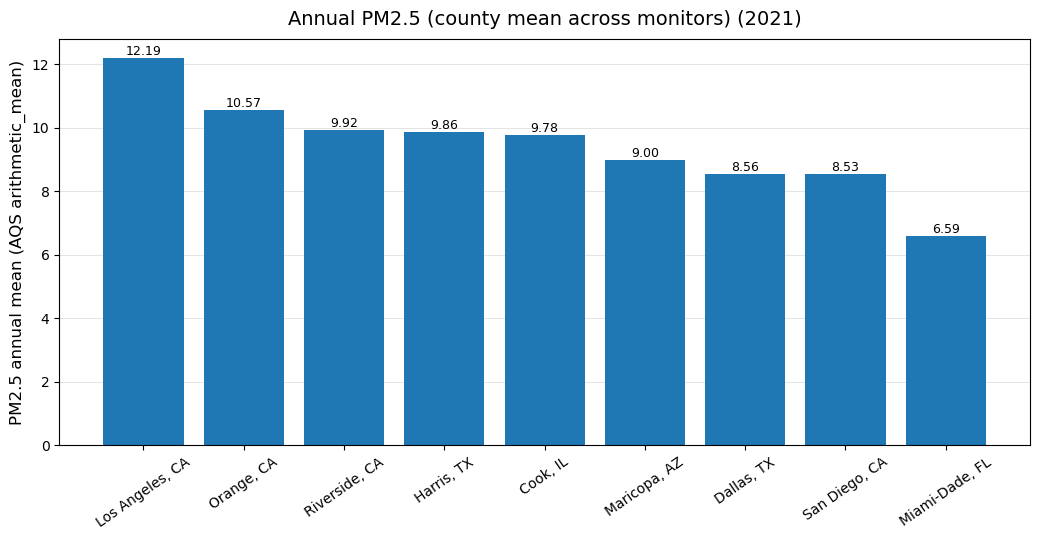

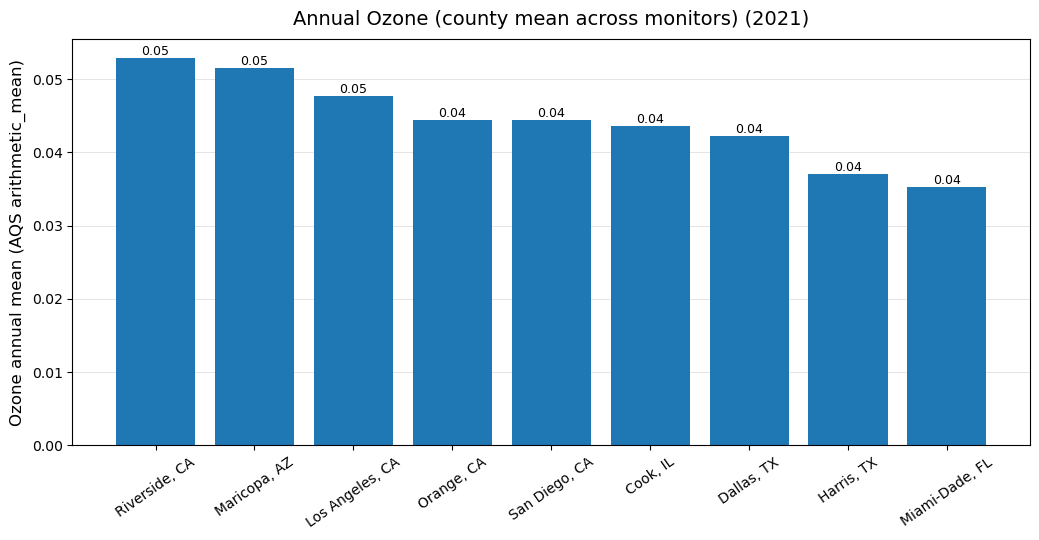

/var/folders/47/h_qs1w2n1p3bbhgw5ddnx8900000gn/T/ipykernel_57542/3868273687.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


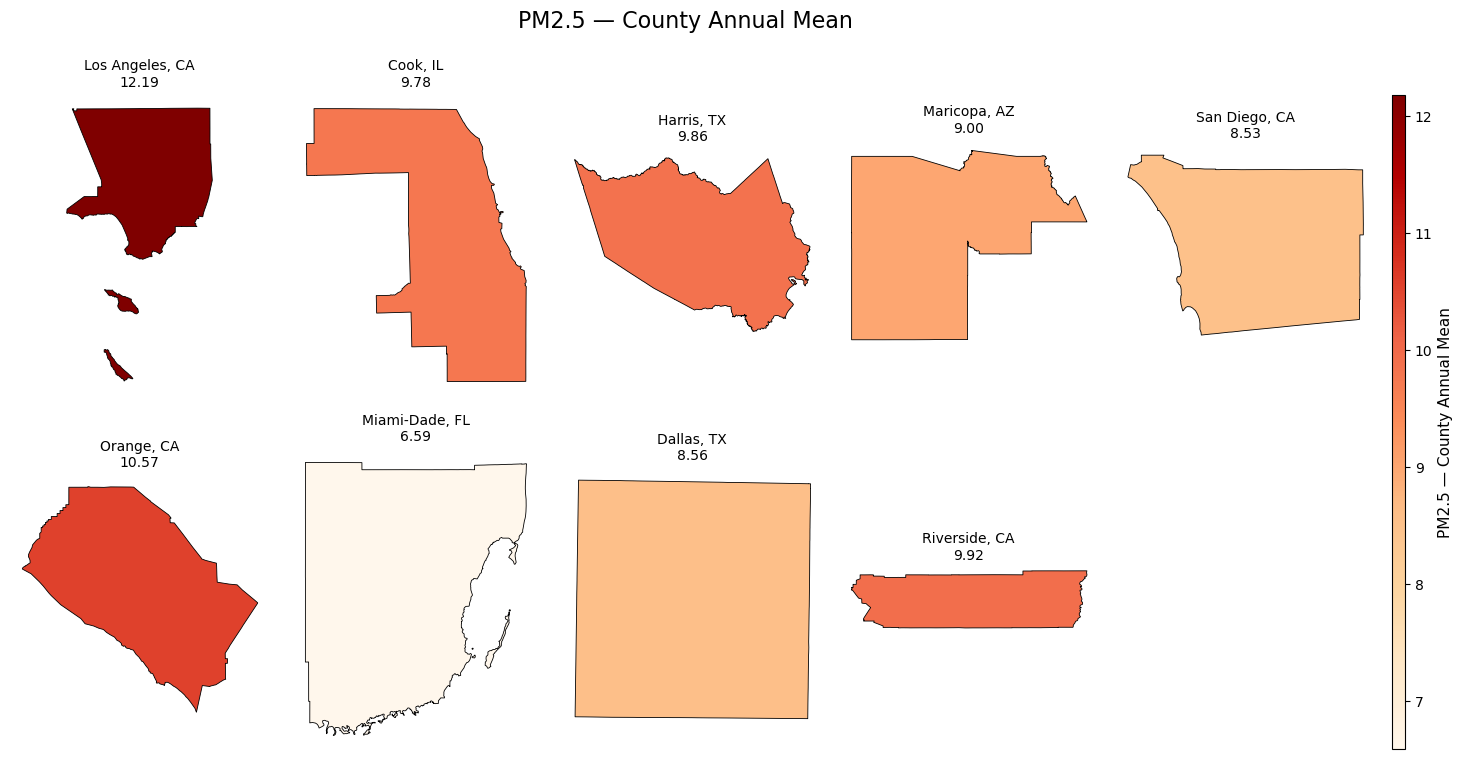

/var/folders/47/h_qs1w2n1p3bbhgw5ddnx8900000gn/T/ipykernel_57542/3868273687.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


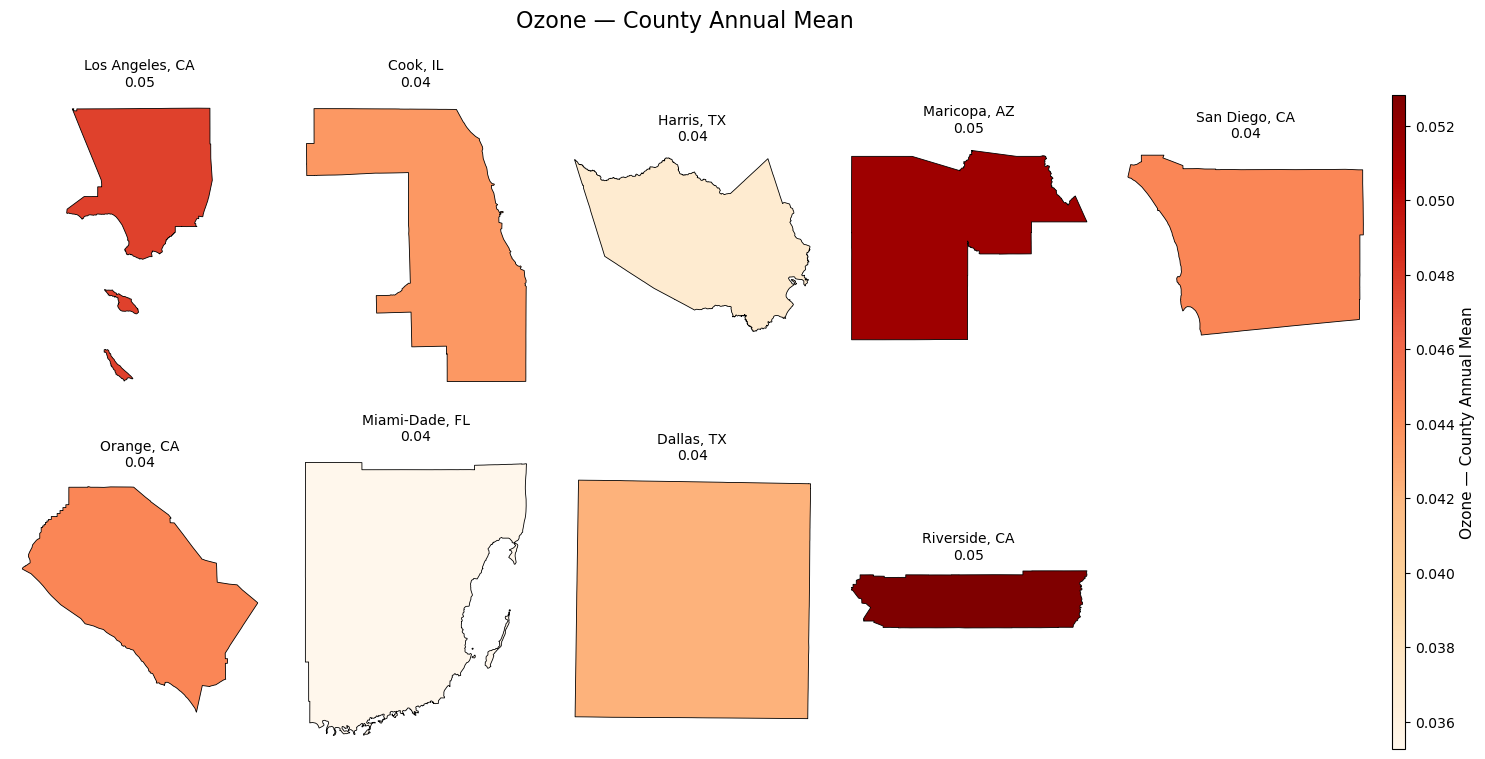

In [22]:

# ----------------------------
#labels for plots
# ----------------------------
DISPLAY_NAMES = {
    "LosAngeles_CA": "Los Angeles, CA",
    "Cook_IL": "Cook, IL",
    "Harris_TX": "Harris, TX",
    "Maricopa_AZ": "Maricopa, AZ",
    "SanDiego_CA": "San Diego, CA",
    "Orange_CA": "Orange, CA",
    "MiamiDade_FL": "Miami-Dade, FL",
    "Dallas_TX": "Dallas, TX",
    "Riverside_CA": "Riverside, CA",
}

# consistent ordering across all figs
COUNTIES_ORDER = list(DISPLAY_NAMES.keys())


# ----------------------------
# Bar chart
# ----------------------------
def plot_ranked_bar(summary_df, title, y_label, value_col="pollution_mean", name_col="county_name"):
    """
    summary_df must contain: county_name, pollution_mean, year_mode
    """
    df = summary_df.copy()
    df["display"] = df[name_col].map(DISPLAY_NAMES).fillna(df[name_col])

    # Sort high -> low
    df = df.sort_values(value_col, ascending=False)

    fig, ax = plt.subplots(figsize=(10.5, 5.5))

    bars = ax.bar(df["display"], df[value_col])

    # value labels on bars
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(f"{title} ({df['year_mode'].iloc[0]})", fontsize=14, pad=10)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.4)
    ax.set_axisbelow(True)

    fig.tight_layout()
    plt.show()


# ----------------------------
# county subplots 
# ----------------------------
def plot_county_subplots_pub(
    gdf,
    value_col,
    vmin,
    vmax,
    title,
    units="",
    cmap="OrRd",          
    nrows=2,
    ncols=5,
):
    """
    gdf must contain: county_name, geometry, and value_col
    Produces a 2x5 grid with a dedicated right-hand colorbar axis.
    (If you have 9 counties, one panel will be blank.)
    """
    # order counties consistently
    order = [c for c in COUNTIES_ORDER if c in set(gdf["county_name"])]

    fig = plt.figure(figsize=(18, 8.5))

    # Make an extra narrow column for the colorbar
    gs = fig.add_gridspec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.08, hspace=0.18)
    axes = [fig.add_subplot(gs[r, c]) for r in range(nrows) for c in range(ncols)]
    cax = fig.add_subplot(gs[:, ncols])

    # Plot each county
    for i, cname in enumerate(order):
        ax = axes[i]
        one = gdf[gdf["county_name"] == cname]

        disp = DISPLAY_NAMES.get(cname, cname)

        if one.empty or one[value_col].isna().all():
            one.boundary.plot(ax=ax, linewidth=1.0)
            ax.set_title(f"{disp}\n(No data)", fontsize=10)
            ax.axis("off")
            continue

        one.plot(
            ax=ax,
            column=value_col,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            legend=False,
            linewidth=0.6,
            edgecolor="black",
        )

        val = one[value_col].iloc[0]
        ax.set_title(f"{disp}\n{val:.2f}{units}", fontsize=10)
        ax.axis("off")

    # turn off unused panels
    for j in range(len(order), len(axes)):
        axes[j].axis("off")

    # Right-side shared colorbar
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)

    cbar.set_label(f"{title}{(' ' + units) if units else ''}", fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    fig.suptitle(title, fontsize=16, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ----------------------------
# 1) Ranked PM2.5 bar chart
# ----------------------------

plot_ranked_bar(
    pm_summary,
    title="Annual PM2.5 (county mean across monitors)",
    y_label="PM2.5 annual mean (AQS arithmetic_mean)",
)

# ----------------------------
# 2) Ranked Ozone bar chart
# ----------------------------

plot_ranked_bar(
    o3_summary,
    title="Annual Ozone (county mean across monitors)",
    y_label="Ozone annual mean (AQS arithmetic_mean)",
)

# ----------------------------
# 3) County subplot maps (PM2.5 + Ozone)
# ----------------------------

plot_county_subplots_pub(
    pm_gdf,
    value_col="pollution_mean",
    vmin=pm_vmin,
    vmax=pm_vmax,
    title="PM2.5 — County Annual Mean",
    units="",      
    cmap="OrRd",
)

plot_county_subplots_pub(
    o3_gdf,
    value_col="pollution_mean",
    vmin=o3_vmin,
    vmax=o3_vmax,
    title="Ozone — County Annual Mean",
    units="",     
    cmap="OrRd",
)

Now I would like to exlpore the per capita pollution levels

In [23]:
# Create the population dataframe
pop_2019_2021 = pd.DataFrame([
    {"county_name": "LosAngeles_CA", "year": 2019, "population": 10010000},
    {"county_name": "LosAngeles_CA", "year": 2021, "population": 9850000},

    {"county_name": "Cook_IL", "year": 2019, "population": 5100000},
    {"county_name": "Cook_IL", "year": 2021, "population": 5200000},

    {"county_name": "Harris_TX", "year": 2019, "population": 4700000},
    {"county_name": "Harris_TX", "year": 2021, "population": 4700000},

    {"county_name": "Maricopa_AZ", "year": 2019, "population": 4500000},
    {"county_name": "Maricopa_AZ", "year": 2021, "population": 4500000},

    {"county_name": "SanDiego_CA", "year": 2019, "population": 3300000},
    {"county_name": "SanDiego_CA", "year": 2021, "population": 3300000},

    {"county_name": "Orange_CA", "year": 2019, "population": 3170000},
    {"county_name": "Orange_CA", "year": 2021, "population": 3170000},

    {"county_name": "MiamiDade_FL", "year": 2019, "population": 2710000},
    {"county_name": "MiamiDade_FL", "year": 2021, "population": 2670000},

    {"county_name": "Dallas_TX", "year": 2019, "population": 2630000},
    {"county_name": "Dallas_TX", "year": 2021, "population": 2600000},

    {"county_name": "Riverside_CA", "year": 2019, "population": 2400000},
    {"county_name": "Riverside_CA", "year": 2021, "population": 2400000},
])

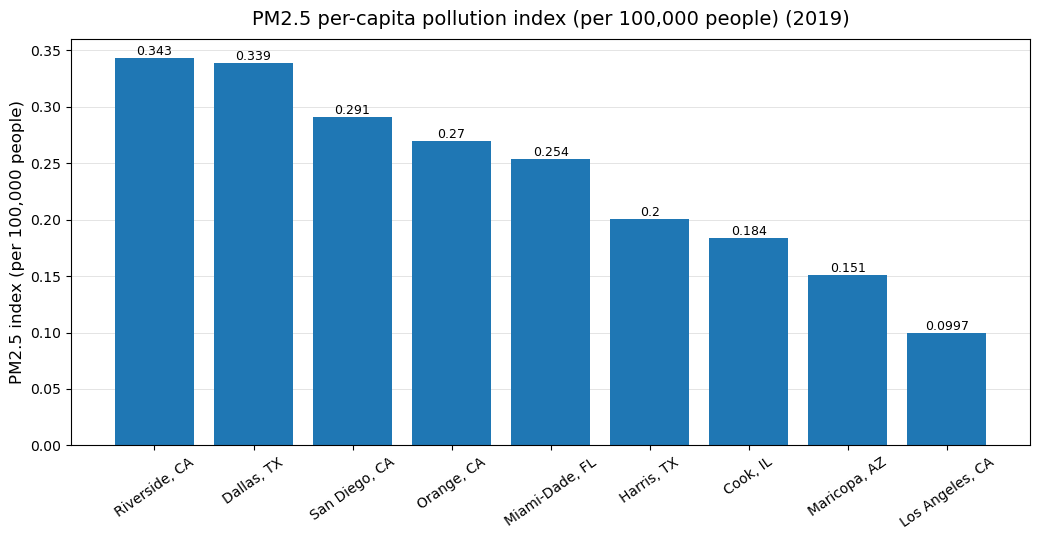

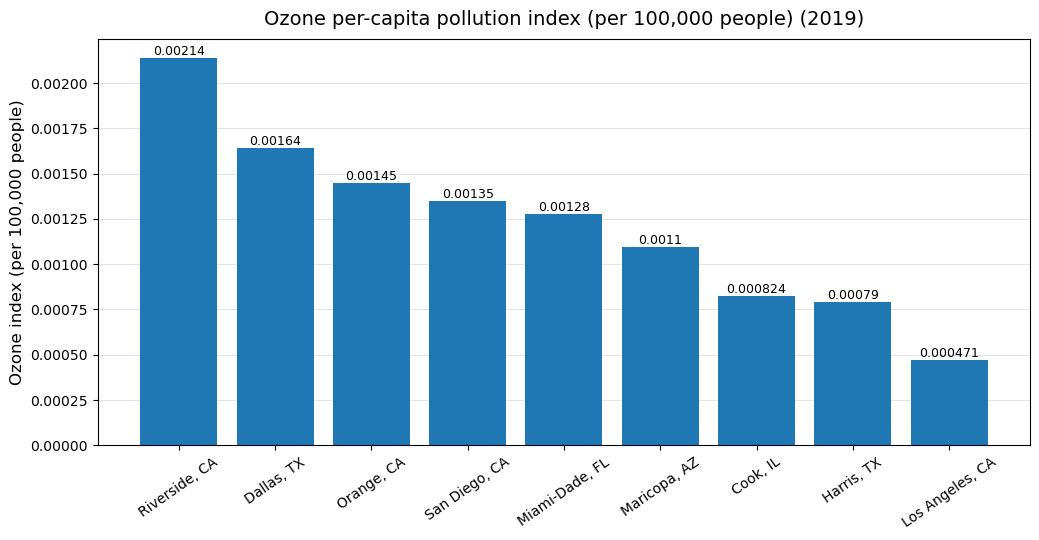

/var/folders/47/h_qs1w2n1p3bbhgw5ddnx8900000gn/T/ipykernel_57542/1664391249.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


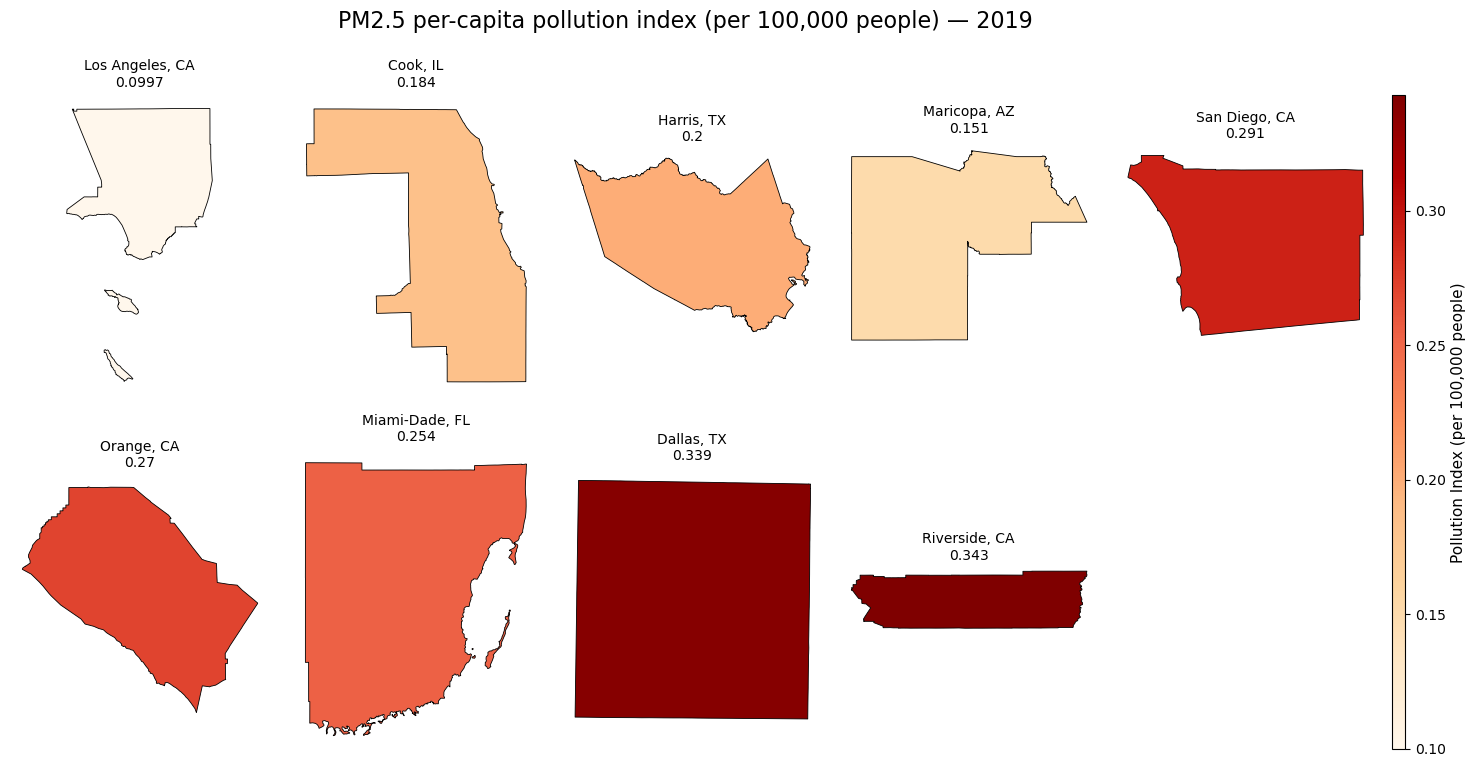

/var/folders/47/h_qs1w2n1p3bbhgw5ddnx8900000gn/T/ipykernel_57542/1664391249.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


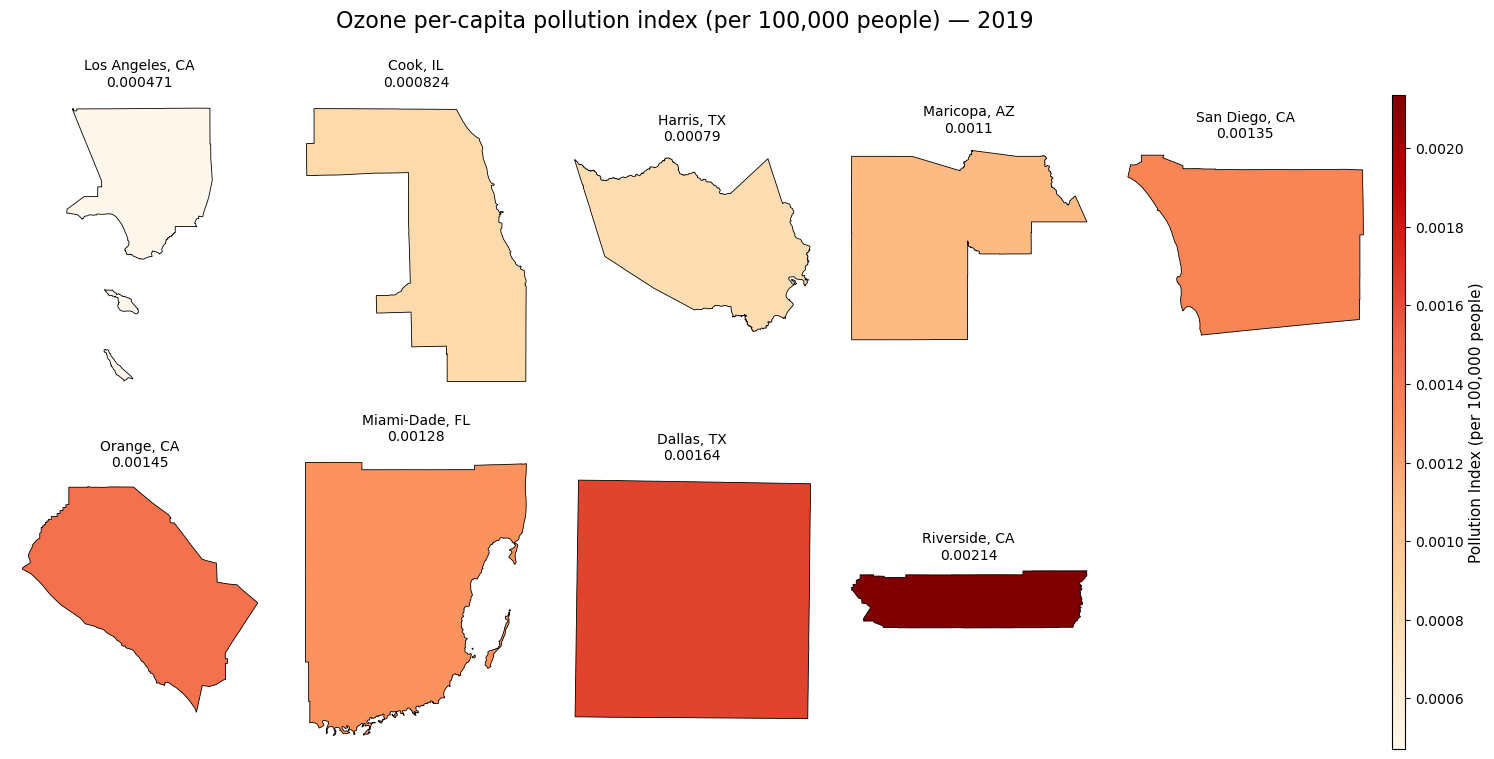

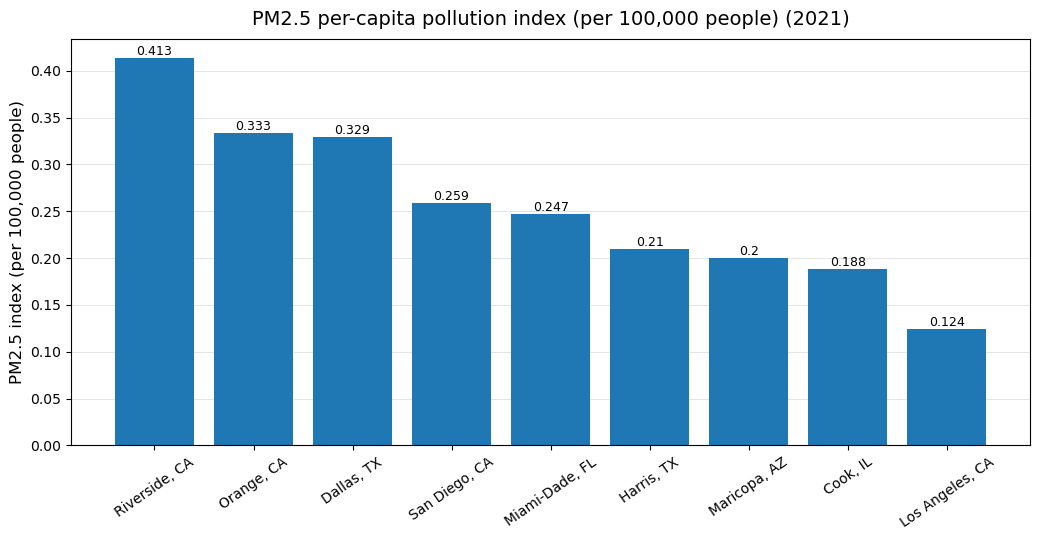

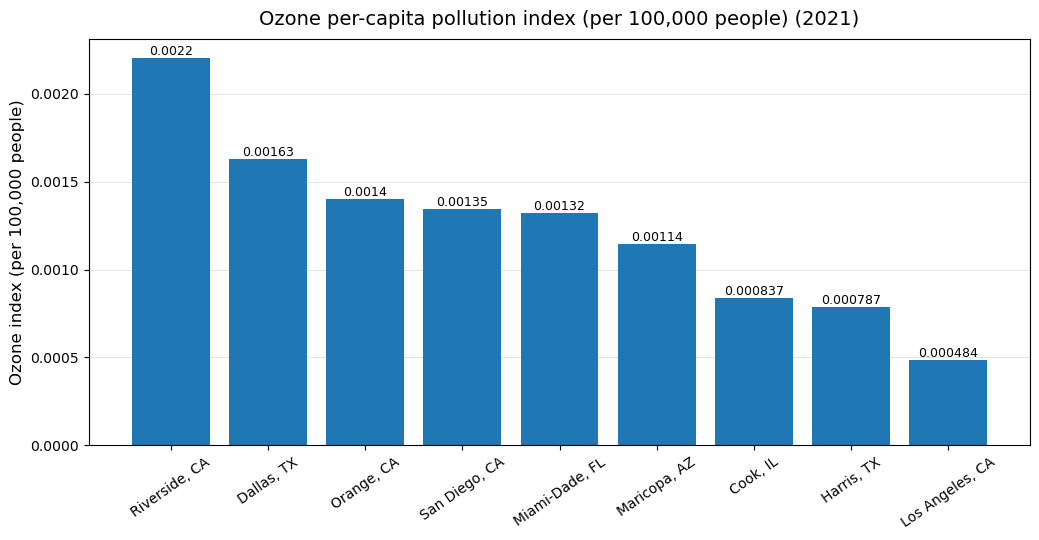

/var/folders/47/h_qs1w2n1p3bbhgw5ddnx8900000gn/T/ipykernel_57542/1664391249.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


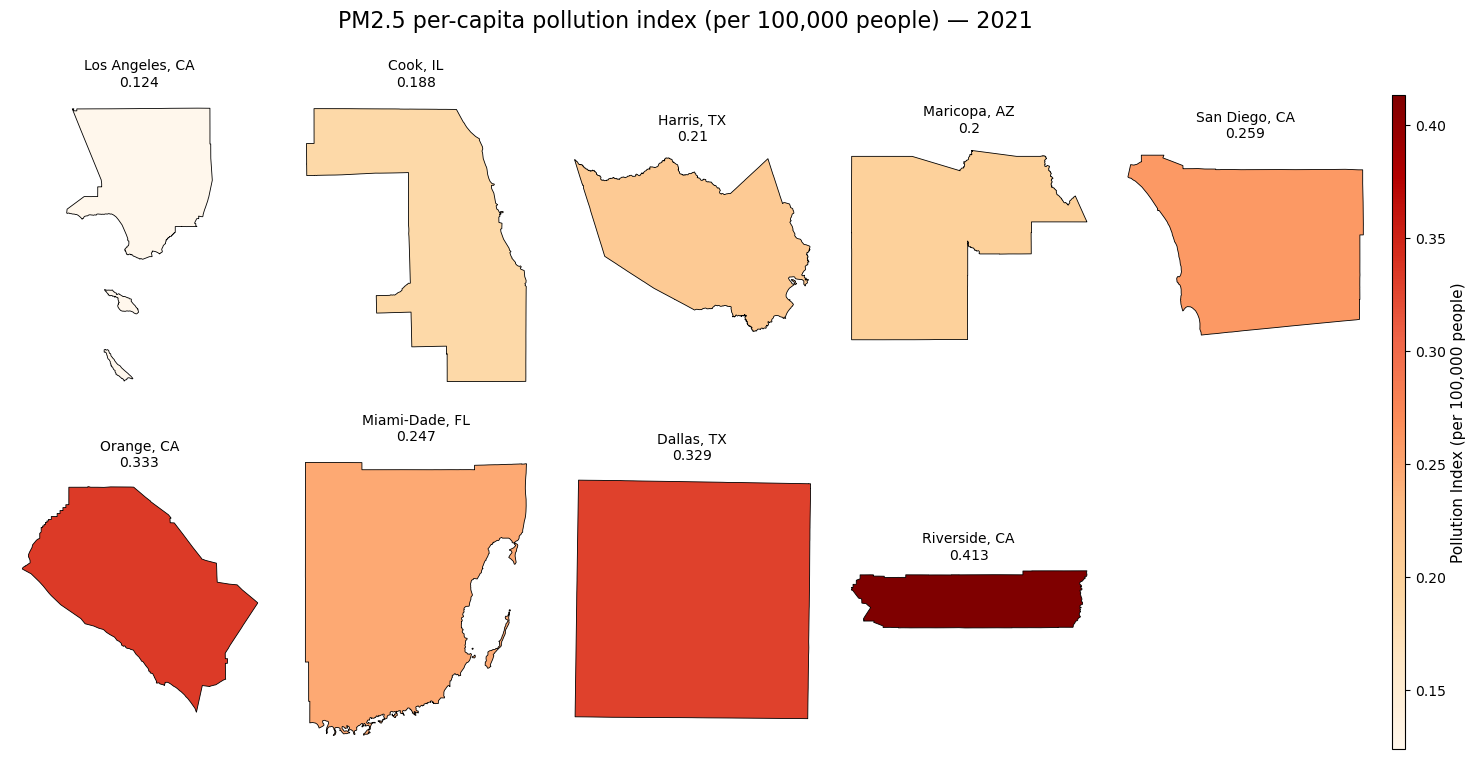

/var/folders/47/h_qs1w2n1p3bbhgw5ddnx8900000gn/T/ipykernel_57542/1664391249.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


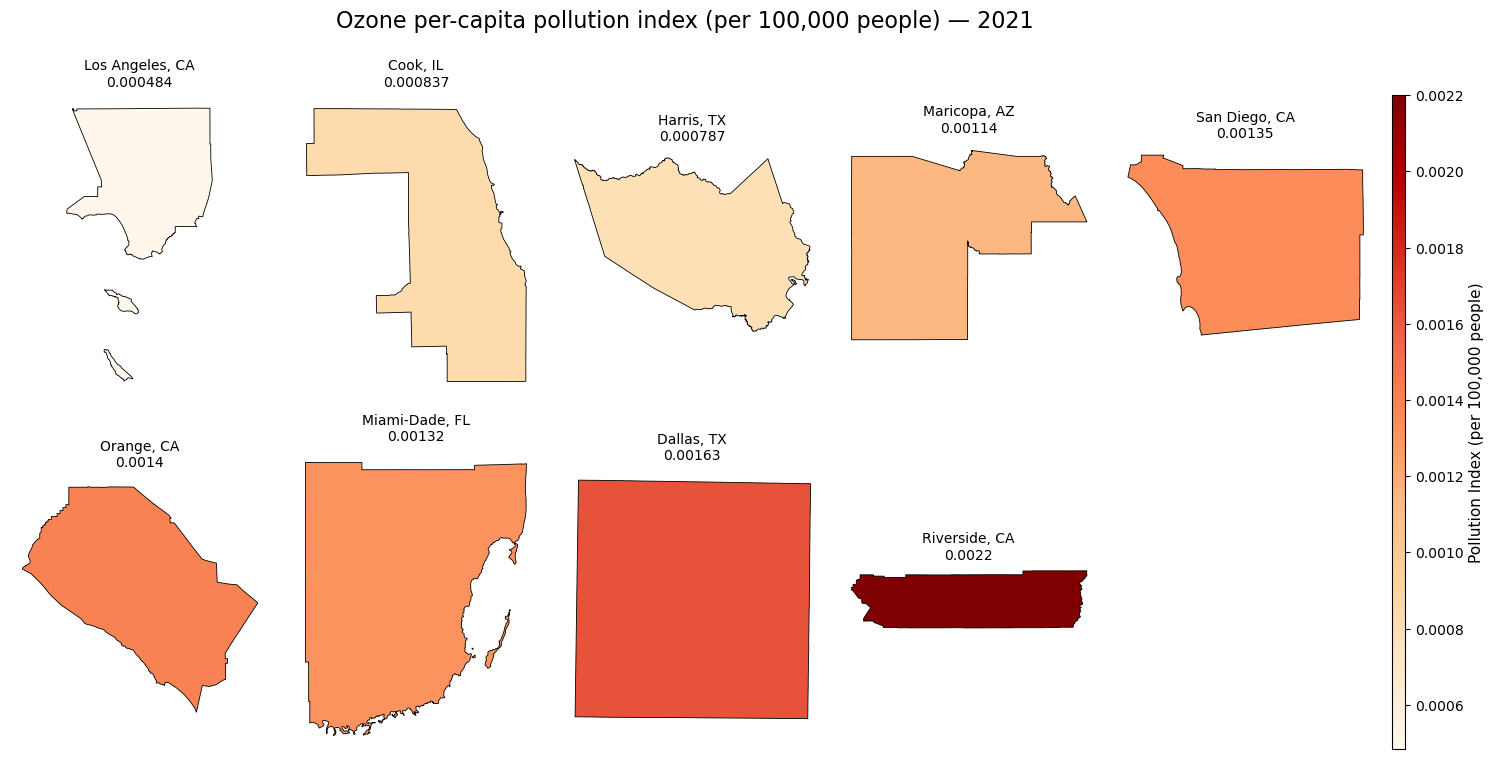

In [24]:
# ----------------------------
# Setup
# ----------------------------
YEARS = [2019, 2021]
POLLUTANTS = ["PM25", "Ozone"]

# scale factor: per 100k people
PER_CAPITA_SCALE = 100_000
PER_CAPITA_LABEL = f"per {PER_CAPITA_SCALE:,} people"

# labels
DISPLAY_NAMES = {
    "LosAngeles_CA": "Los Angeles, CA",
    "Cook_IL": "Cook, IL",
    "Harris_TX": "Harris, TX",
    "Maricopa_AZ": "Maricopa, AZ",
    "SanDiego_CA": "San Diego, CA",
    "Orange_CA": "Orange, CA",
    "MiamiDade_FL": "Miami-Dade, FL",
    "Dallas_TX": "Dallas, TX",
    "Riverside_CA": "Riverside, CA",
}

COUNTIES_ORDER = list(DISPLAY_NAMES.keys())

# county fips lookup (same as earlier workflow, Kings removed)
COUNTY_FIPS = {
    "LosAngeles_CA": ("06", "037"),
    "Cook_IL": ("17", "031"),
    "Harris_TX": ("48", "201"),
    "Maricopa_AZ": ("04", "013"),
    "SanDiego_CA": ("06", "073"),
    "Orange_CA": ("06", "059"),
    "MiamiDade_FL": ("12", "086"),
    "Dallas_TX": ("48", "113"),
    "Riverside_CA": ("06", "065"),
}


# ----------------------------
# Build county-year mean concentrations from AQS
# ----------------------------
def county_year_concentration(aqs_df: pd.DataFrame, pollutant: str) -> pd.DataFrame:
    df = aqs_df.copy()
    df["arithmetic_mean"] = pd.to_numeric(df["arithmetic_mean"], errors="coerce")
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

    df = df[df["county_name"].isin(COUNTIES_ORDER)]
    df = df[df["pollutant"] == pollutant]
    df = df[df["year"].isin(YEARS)]

    out = (
        df.groupby(["county_name", "year"], as_index=False)
          .agg(
              concentration_mean=("arithmetic_mean", "mean"),
              monitor_count=("arithmetic_mean", "count"),
          )
    )
    out["pollutant"] = pollutant
    return out

pm_cy = county_year_concentration(aqs_df, "PM25")
o3_cy = county_year_concentration(aqs_df, "Ozone")
conc_cy = pd.concat([pm_cy, o3_cy], ignore_index=True)

# join population
cy = conc_cy.merge(pop_2019_2021, on=["county_name", "year"], how="left")

missing = cy[cy["population"].isna()]
if len(missing) > 0:
    raise ValueError(f"Missing population for some rows:\n{missing[['county_name','year','pollutant']]}")

# compute per-capita metric (per 100k people by default)
cy["pollution_per_capita"] = (cy["concentration_mean"] / cy["population"]) * PER_CAPITA_SCALE


# ----------------------------
# 3) Bar plot (ranked) for ONE pollutant + ONE year
# ----------------------------
def plot_ranked_bar_one(df, pollutant, year, title_prefix, y_label):
    d = df[(df["pollutant"] == pollutant) & (df["year"] == year)].copy()
    d["display"] = d["county_name"].map(DISPLAY_NAMES).fillna(d["county_name"])
    d = d.sort_values("pollution_per_capita", ascending=False)

    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    bars = ax.bar(d["display"], d["pollution_per_capita"])

    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            h,
            f"{h:.3g}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(f"{title_prefix} ({year})", fontsize=14, pad=10)
    ax.set_ylabel(y_label, fontsize=12)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.4)
    ax.set_axisbelow(True)
    fig.tight_layout()
    plt.show()


# ----------------------------
# 4) County shape subplot maps (ONE pollutant + ONE year)
# ----------------------------
# Load county geometries once
COUNTY_SHAPE_URL = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip"
us_counties = gpd.read_file(COUNTY_SHAPE_URL)
us_counties["GEOID"] = us_counties["STATEFP"] + us_counties["COUNTYFP"]

fips_df = pd.DataFrame(
    [{"county_name": cname, "GEOID": f"{st}{cty}"} for cname, (st, cty) in COUNTY_FIPS.items()]
)

sel_gdf = us_counties.merge(fips_df, on="GEOID", how="inner")

def plot_county_subplots_pub_one(gdf_geo, df_values, pollutant, year, title, cmap="OrRd"):
    """
    gdf_geo: geometry for selected counties (has county_name + GEOID + geometry)
    df_values: county-year values with pollution_per_capita
    """
    vals = df_values[(df_values["pollutant"] == pollutant) & (df_values["year"] == year)][
        ["county_name", "pollution_per_capita"]
    ].copy()

    gdf = gdf_geo.merge(vals, on="county_name", how="left")

    vmin = gdf["pollution_per_capita"].min()
    vmax = gdf["pollution_per_capita"].max()

    nrows, ncols = 2, 5
    fig = plt.figure(figsize=(18, 8.5))
    gs = fig.add_gridspec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.08, hspace=0.18)
    axes = [fig.add_subplot(gs[r, c]) for r in range(nrows) for c in range(ncols)]
    cax = fig.add_subplot(gs[:, ncols])

    for i, cname in enumerate(COUNTIES_ORDER):
        ax = axes[i]
        one = gdf[gdf["county_name"] == cname]
        disp = DISPLAY_NAMES.get(cname, cname)

        if one.empty or one["pollution_per_capita"].isna().all():
            one.boundary.plot(ax=ax, linewidth=1.0)
            ax.set_title(f"{disp}\n(No data)", fontsize=10)
            ax.axis("off")
            continue

        one.plot(
            ax=ax,
            column="pollution_per_capita",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            legend=False,
            linewidth=0.6,
            edgecolor="black",
        )

        val = one["pollution_per_capita"].iloc[0]
        ax.set_title(f"{disp}\n{val:.3g}", fontsize=10)
        ax.axis("off")

    # Turn off unused panel (#10) since we have 9 counties
    for j in range(len(COUNTIES_ORDER), len(axes)):
        axes[j].axis("off")

    # shared colorbar on far right
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(f"Pollution Index ({PER_CAPITA_LABEL})", fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    fig.suptitle(f"{title} — {year}", fontsize=16, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ----------------------------
# Visualizations
# ----------------------------
for year in YEARS:
    # PM2.5 bar
    plot_ranked_bar_one(
        cy, pollutant="PM25", year=year,
        title_prefix=f"PM2.5 per-capita pollution index ({PER_CAPITA_LABEL})",
        y_label=f"PM2.5 index ({PER_CAPITA_LABEL})"
    )

    # Ozone bar
    plot_ranked_bar_one(
        cy, pollutant="Ozone", year=year,
        title_prefix=f"Ozone per-capita pollution index ({PER_CAPITA_LABEL})",
        y_label=f"Ozone index ({PER_CAPITA_LABEL})"
    )

    # PM2.5 map
    plot_county_subplots_pub_one(
        sel_gdf, cy, pollutant="PM25", year=year,
        title=f"PM2.5 per-capita pollution index ({PER_CAPITA_LABEL})",
        cmap="OrRd"
    )

    # Ozone map
    plot_county_subplots_pub_one(
        sel_gdf, cy, pollutant="Ozone", year=year,
        title=f"Ozone per-capita pollution index ({PER_CAPITA_LABEL})",
        cmap="OrRd"
    )